In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
from lib.models import RegNetv3
from lib.data.dataloading import load_nursing_5_class
from lib.modules import optimization_loop_multi_class, evaluate_loop
import torch
from torch import nn
import matplotlib.pyplot as plt
import json
import numpy as np
from lib.utils import sample_regnet
from tqdm import tqdm

In [5]:
import pandas as pd
from pathlib import Path
import json

df = pd.DataFrame(columns=['n', 'd', 'w', 'nparams', 'best_f1', 'best_loss'])

for model_dir in Path('dev/n-search-shared').iterdir():
    config = json.load(open(model_dir / 'config.json'))
    info = json.load(open(model_dir / 'info.json'))
    nparams = sum([param.numel() for param in RegNetv3(CONFIG=config).parameters()])
    df.loc[len(df)] = {
        'n': int(config['N']),
        'd': config['DEPTHI'],
        'w': config['WIDTHI'],
        'nparams': nparams,
        'best_f1': sum(info['f1']) / len(info['f1']),
        'best_loss': info['loss']
    }
df['dw_str'] = df['d'].astype(str) + '-' + df['w'].astype(str)

In [6]:
df[df.n==30].sort_values('best_f1', ascending=False).head(10)

,n,d,w,nparams,best_f1,best_loss,dw_str
26,30,[1],[56],12311,0.693871,0.761539,[1]-[56]
140,30,"[2, 4, 3]","[16, 32, 96]",83607,0.693117,0.768861,"[2, 4, 3]-[16, 32, 96]"
21,30,"[1, 4, 8, 7]","[48, 112, 256, 592]",8559911,0.687280,1.800611,"[1, 4, 8, 7]-[48, 112, 256, 592]"
16,30,"[2, 4]","[56, 112]",160599,0.687043,0.793960,"[2, 4]-[56, 112]"
56,30,[2],[48],16647,0.684214,0.777739,[2]-[48]
38,30,"[2, 2]","[56, 120]",92535,0.679575,0.878021,"[2, 2]-[56, 120]"
44,30,"[1, 2]","[24, 48]",15903,0.678249,0.811275,"[1, 2]-[24, 48]"
93,30,"[2, 5, 9]","[64, 176, 496]",6706183,0.677437,0.776707,"[2, 5, 9]-[64, 176, 496]"
18,30,"[1, 2, 2]","[8, 24, 64]",23799,0.676884,0.787831,"[1, 2, 2]-[8, 24, 64]"
47,30,"[3, 9, 8]","[32, 88, 248]",1591991,0.671759,0.960473,"[3, 9, 8]-[32, 88, 248]"


In [21]:
df.sort_values('best_f1', ascending=False).head(5)

,n,d,w,nparams,best_f1,best_loss,dw_str
149,40,"[1, 2]","[40, 88]",45263,0.724196,0.690338,"[1, 2]-[40, 88]"
42,50,"[1, 2, 2]","[16, 88, 232]",277071,0.722189,0.695923,"[1, 2, 2]-[16, 88, 232]"
7,40,"[1, 2]","[24, 48]",15903,0.710164,0.784932,"[1, 2]-[24, 48]"
55,40,[2],[48],16647,0.708573,0.732008,[2]-[48]
13,50,[2],[48],16647,0.707029,0.724785,[2]-[48]


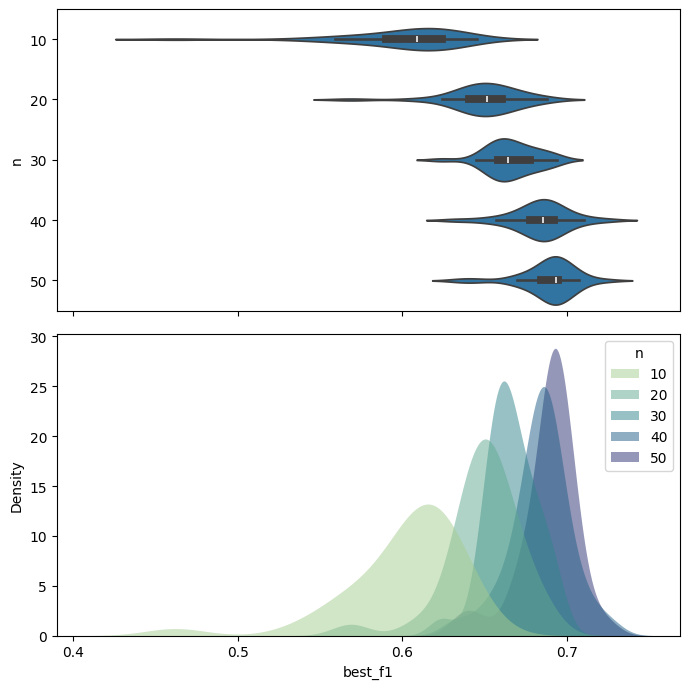

In [22]:
import seaborn as sns
fig, axes = plt.subplots(2, 1, figsize=(7,7), sharex=True)
sns.violinplot(data=df, x='best_f1', y='n', orient='h', ax=axes[0])
sns.kdeplot(data=df, x='best_f1', hue='n', fill=True, common_norm=False, alpha=0.5, palette='crest', linewidth=0, ax=axes[1])
start, end = axes[0].get_xlim()
plt.xticks(np.arange(start.round(1), end, 0.1))
plt.tight_layout()

In [91]:
df

,n,d,w,nparams,best_f1,best_loss,dw_str,nparams_binned
0,10,"[1, 1, 1]","[8, 40, 80]",17007,0.591326,0.923099,"[1, 1, 1]-[8, 40, 80]",<20000.0
1,20,"[3, 10, 7]","[56, 120, 240]",1603079,0.654011,0.846016,"[3, 10, 7]-[56, 120, 240]",>1600000.0
2,40,[1],[32],5591,0.649298,0.795425,[1]-[32],<20000.0
3,40,"[3, 10, 7]","[56, 120, 240]",1603079,0.697072,0.753215,"[3, 10, 7]-[56, 120, 240]",>1600000.0
4,10,[1],[56],12311,0.588726,0.972457,[1]-[56],<20000.0
...,...,...,...,...,...,...,...,...
150,10,"[1, 1, 3, 1]","[16, 32, 80, 216]",124655,0.612546,0.973047,"[1, 1, 3, 1]-[16, 32, 80, 216]",120000.0-1600000.0
151,50,"[3, 9, 8]","[32, 88, 248]",1591991,0.694550,0.768716,"[3, 9, 8]-[32, 88, 248]",120000.0-1600000.0
152,50,"[3, 9, 8]","[56, 152, 384]",3956447,0.694405,1.327445,"[3, 9, 8]-[56, 152, 384]",>1600000.0
153,10,"[3, 10, 7]","[56, 120, 240]",1603079,0.620953,0.933224,"[3, 10, 7]-[56, 120, 240]",>1600000.0


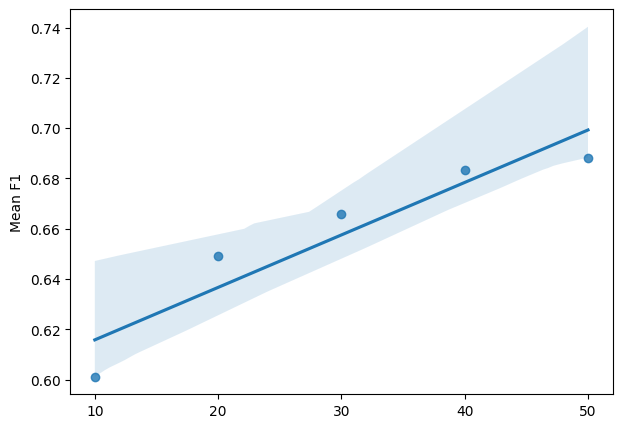

In [100]:
fig,ax = plt.subplots(1, figsize=(7,5), sharex=True)
dfbyn = df.groupby('n', as_index=False).mean(numeric_only=True)
sns.regplot(data=dfbyn, x='n', y='best_f1', ax=ax)
ax.set_ylabel('Mean F1')
ax.set_xlabel('')
ax.set_xticks(range(10, 60, 10));

# discretize nparams
# bins = df.nparams.quantile([0, 0.25, 0.5, 0.75, 1]).apply(lambda x: round(x, -4))
# df['nparams_binned'] = pd.cut(df.nparams, bins=bins, labels=[f'<{bins[0.25]}' , f'{bins[0.25]}-{bins[0.5]}', f'{bins[0.5]}-{bins[0.75]}', f'>{bins[0.75]}'])
# sns.boxplot(data=df, x='n', y='best_f1', hue='nparams_binned', ax=axes[1])
# axes[1].set_xticks(range(10, 60, 10))

# Data Augmentation

In [1]:
from lib.data.datasets import WindowedDatasetWithStrideAndModeOfLabel, DataAug
from lib.data.dataloading import load_nursing_aug, load_nursing_5_class
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset, Dataset
import os

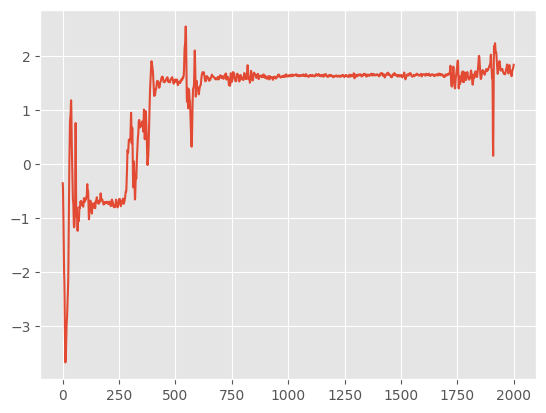

In [63]:

import torch.nn.functional as F

x = F.interpolate(x.unsqueeze(0), x.shape[-1]*8, mode='linear')
x = F.interpolate(x, x.shape[-1]//8).squeeze(0)

  0%|          | 0/500 [00:00<?, ?it/s]

: Epoch 1: Train Loss: 1.4914: Dev Loss: 1.4233, Dev F1: 0.14201:   0%|          | 1/500 [00:02<21:11,  2.55s/it]


KeyboardInterrupt: 

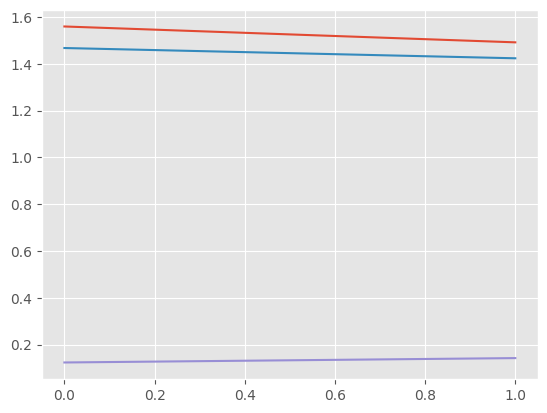

In [34]:
from sklearn.model_selection import train_test_split
from lib.models import RegNetv3
from lib.modules import optimization_loop_multi_class
import torch
from torch import nn

CONFIG = {
    'WINDOW_SIZE':2001,
    'NURSING_STRIDE': 2001 // 16,
    'BATCH_SIZE': 512,
    'LEARNING_RATE': 3e-4,
    'NURSING_TEST_SIZE': 0.15,
    'DEVICE': 'cuda:0',
    'DEPTHI': [1],
    'WIDTHI': [56],
    'AUG_METHOD': 'swap_channels'
}

def swap_channels(x):
    idxs = np.random.permutation(3)
    x = x[idxs]
    return x


n = 30
nurses = np.random.choice(list(range(11,71)), n, replace=False)
train_nurses, dev_nurses = train_test_split(nurses, test_size=CONFIG['NURSING_TEST_SIZE'])
CONFIG['TRAIN_NURSES'] = train_nurses.tolist()
CONFIG['VALIDATION'] = dev_nurses.tolist()
nursing_trainloader, nursing_testloader = load_nursing_aug(
    split=(train_nurses, dev_nurses),
    winsize=CONFIG['WINDOW_SIZE'],
    batch_size=CONFIG['BATCH_SIZE'],
    stride=CONFIG['NURSING_STRIDE'],
    dataaug=swap_channels
)

model = RegNetv3(CONFIG=CONFIG).to(CONFIG['DEVICE'])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'])

outdir = f'dev/data_aug_swap2'
optimization_loop_multi_class(
    model,
    nursing_trainloader,
    nursing_testloader,
    criterion,
    optimizer,
    epochs=500,
    patience=30,
    device=CONFIG['DEVICE'],
    outdir=outdir,
    writer=outdir,
    config=CONFIG,
    continue_training=False
)

In [163]:
import plotly.express as px
X,y = torch.load(f'{DATA_DIR}/12.pt')
# add noise to X
logits = X + torch.randn_like(X) * 0.2

X = X.T
logits = logits.T
i = slice(0,10)
df = pd.DataFrame({
    'x_true': X[0].flatten(), 
    'y_true': X[1].flatten(), 
    'z_true': X[2].flatten(), 
    'x_pred': logits[0].flatten(), 
    'y_pred': logits[1].flatten(), 
    'z_pred': logits[2].flatten()
})
fig = px.line(df[::10], x=df.index[::10], y=['x_true', 'x_pred', 'y_true', 'y_pred', 'z_true', 'z_pred'])
fig.show(renderer='browser')